# Pitch Predictions - XGBoost


## Imports and Loading Data

In [70]:
import numpy as np
import pandas as pd
import pickle
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
 
print("Imports successful")
 
# Load data
print("\nLoading feature data...")
X_train = np.load('../../feature-engineering/X_train.npy')
X_test = np.load('../../feature-engineering/X_test.npy')
y_train = np.load('../../feature-engineering/y_train.npy')
y_test = np.load('../../feature-engineering/y_test.npy')
 
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
 
# Load feature names and encoder
with open('../../feature-engineering/feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)
 
with open('../../feature-engineering/pitch_type_encoder.pkl', 'rb') as f:
    pitch_encoder = pickle.load(f)
 
print(f"\nLoaded {len(feature_names)} features and {len(pitch_encoder.classes_)} pitch types")

Imports successful

Loading feature data...
X_train shape: (481704, 26)
X_test shape: (115235, 26)
y_train shape: (481704,)
y_test shape: (115235,)

Loaded 26 features and 12 pitch types


## Baseline accuracy

In [71]:
# Most common pitch in training set
unique, counts = np.unique(y_train, return_counts=True)
most_common_pitch_idx = unique[np.argmax(counts)]
most_common_pitch = pitch_encoder.classes_[most_common_pitch_idx]
baseline_accuracy = np.max(counts) / len(y_train)
 
print(f"\nMost common pitch: {most_common_pitch}")
print(f"Baseline accuracy (train): {baseline_accuracy:.1%}")
 
# Baseline on test set (always predict most common)
baseline_test_accuracy = (y_test == most_common_pitch_idx).sum() / len(y_test)
print(f"Baseline accuracy (test): {baseline_test_accuracy:.1%}")
 
print(f"\nTARGET: Beat {baseline_test_accuracy:.1%} accuracy")


Most common pitch: FF
Baseline accuracy (train): 30.9%
Baseline accuracy (test): 30.1%

TARGET: Beat 30.1% accuracy


## Training

In [72]:
# Tuned for multi-class pitch prediction
model = XGBClassifier(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,  # Use all cores
    verbose=1,
    tree_method='hist',  # Fast histogram-based method
)
 
print("\nTraining (this may take 30-60 seconds)...")
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
 
print("Training complete!")


Training (this may take 30-60 seconds)...
Training complete!


## Evaluation on Test Set

In [73]:
from sklearn.metrics import balanced_accuracy_score, f1_score

# Predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)
 
# Accuracy
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)
 
print(f"\nAccuracy:")
print(f"  Train: {train_accuracy:.3f} ({train_accuracy:.1%})")
print(f"  Test:  {test_accuracy:.3f} ({test_accuracy:.1%})")
print(f"  Baseline: {baseline_test_accuracy:.1%}")
print(f"  Improvement over baseline: +{(test_accuracy - baseline_test_accuracy):.1%}")
 
# Per-pitch accuracy
print(f"\nPer-pitch type accuracy (test set):")
pitch_types = pitch_encoder.classes_
for i, pitch in enumerate(pitch_types):
    mask = y_test == i
    if mask.sum() > 0:
        acc = accuracy_score(y_test[mask], y_pred_test[mask])
        count = mask.sum()
        print(f"  {pitch:3s}: {acc:.1%} ({count:6d} pitches)")

print("\nAccuracy:", accuracy_score(y_test, y_pred_test))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_test))
print("Macro F1:", f1_score(y_test, y_pred_test, average='macro'))
print("Weighted F1:", f1_score(y_test, y_pred_test, average='weighted'))


Accuracy:
  Train: 0.490 (49.0%)
  Test:  0.437 (43.7%)
  Baseline: 30.1%
  Improvement over baseline: +13.5%

Per-pitch type accuracy (test set):
  CH : 32.4% ( 13925 pitches)
  CU : 4.3% (  5017 pitches)
  EP : 99.1% (   234 pitches)
  FC : 26.3% (  8853 pitches)
  FF : 65.3% ( 34717 pitches)
  FS : 35.7% (  2783 pitches)
  KC : 10.6% (  3493 pitches)
  SI : 54.9% ( 20901 pitches)
  SL : 27.7% ( 15324 pitches)
  ST : 32.7% (  9988 pitches)

Accuracy: 0.43653403913741484
Balanced Accuracy: 0.3891312447872617
Macro F1: 0.40324838310254474
Weighted F1: 0.4137872241779462


## Confusion Matrix


Most common confusions (predicted != actual):
  Actual CH -> Predicted FF:  6819 times ( 49.0%)
  Actual KN -> Predicted FF:  6752 times (  0.0%)
  Actual KC -> Predicted FF:  3919 times (112.2%)
  Actual SI -> Predicted FF:  3307 times ( 15.8%)
  Actual FC -> Predicted FF:  3061 times ( 34.6%)
  Actual FF -> Predicted CH:  3002 times (  8.6%)
  Actual FF -> Predicted KC:  2939 times (  8.5%)
  Actual KN -> Predicted KC:  2917 times (  0.0%)
  Actual CU -> Predicted FF:  2478 times ( 49.4%)
  Actual FF -> Predicted KN:  2431 times (  7.0%)
  Actual SI -> Predicted KC:  2106 times ( 10.1%)
  Actual FC -> Predicted KC:  1930 times ( 21.8%)
  Actual FS -> Predicted FF:  1718 times ( 61.7%)
  Actual FF -> Predicted SI:  1560 times (  4.5%)
  Actual KC -> Predicted KN:  1461 times ( 41.8%)

Generating confusion matrix heatmap...
Saved xgboost_confusion_matrix.png


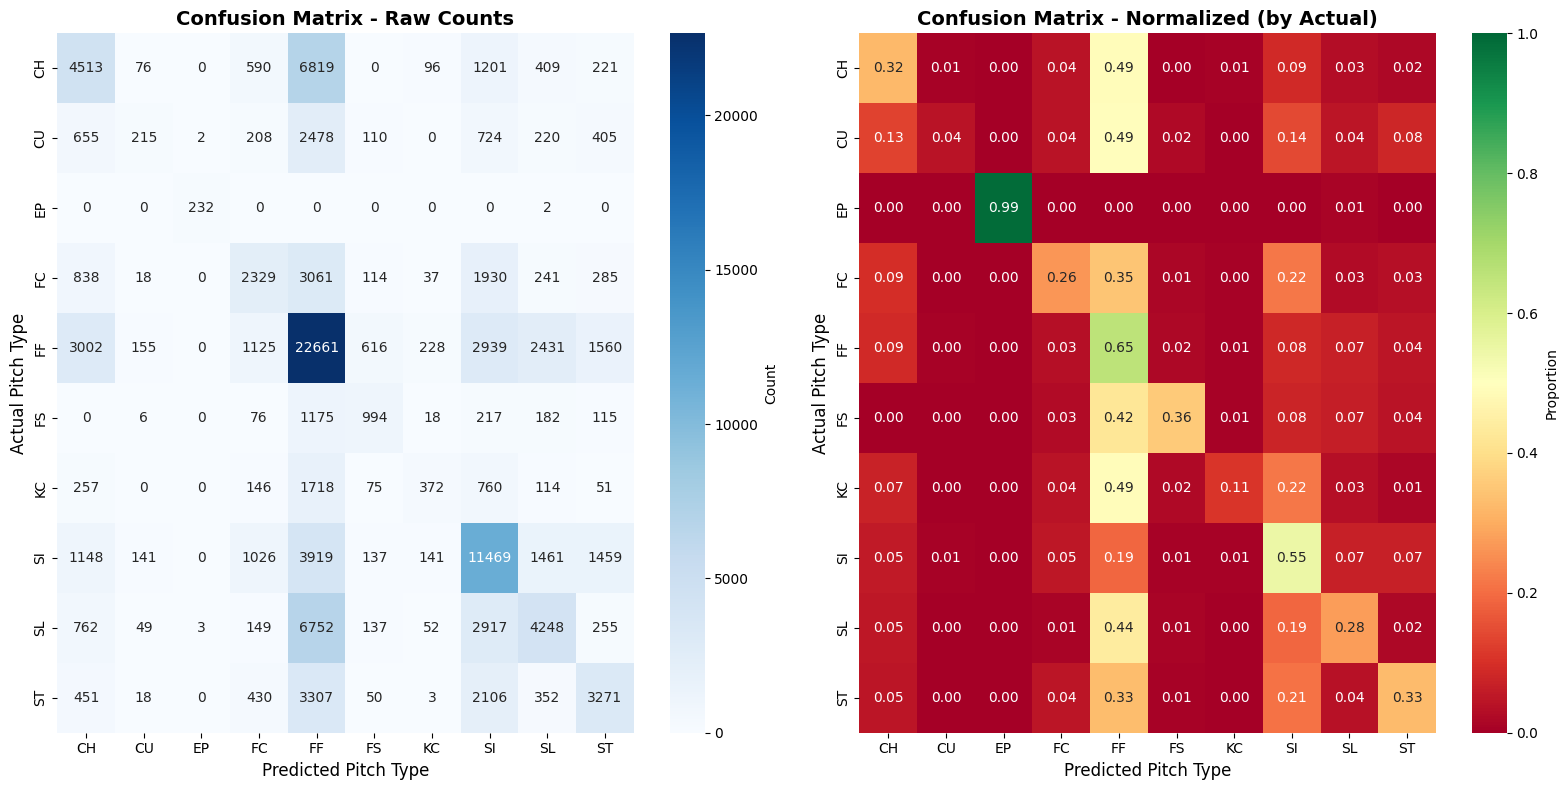

In [74]:
# TODO: Print a matrix visualization
cm = confusion_matrix(y_test, y_pred_test)
 
print("\nMost common confusions (predicted != actual):")
confusions = []
 
# Handle case where test set doesn't have all pitch types
# cm shape is (n_actual_classes, n_predicted_classes)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if i != j:
            count = cm[i, j]
            if count > 0:
                # Get pitch names - handle missing classes
                actual_pitch = pitch_types[i] if i < len(pitch_types) else f"Unknown_{i}"
                pred_pitch = pitch_types[j] if j < len(pitch_types) else f"Unknown_{j}"
                confusions.append((actual_pitch, pred_pitch, count))
 
# Sort by frequency
confusions.sort(key=lambda x: x[2], reverse=True)
for actual, predicted, count in confusions[:15]:
    # Calculate percentage safely
    actual_idx = np.where(pitch_types == actual)[0]
    if len(actual_idx) > 0:
        total_actual = (y_test == actual_idx[0]).sum()
        pct = count / total_actual * 100 if total_actual > 0 else 0
        print(f"  Actual {actual} -> Predicted {predicted}: {count:5d} times ({pct:5.1f}%)")


# Confusion Matrix Heatmap
print("\nGenerating confusion matrix heatmap...")
 
# Create a DataFrame for the confusion matrix with pitch type labels
# Normalize by row (actual pitch type) to show percentages
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
 
# Get the actual pitch types that appear in the test set
actual_pitch_indices = np.unique(y_test)
predicted_pitch_indices = np.unique(y_pred_test)
 
# Get pitch type labels
actual_pitches = pitch_types[actual_pitch_indices]
predicted_pitches = pitch_types[predicted_pitch_indices]
 
# Create heatmap (may be rectangular if different pitches appear in actual vs predicted)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
 
# Count-based heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=predicted_pitches, yticklabels=actual_pitches,
            cbar_kws={'label': 'Count'}, ax=ax1)
ax1.set_title('Confusion Matrix - Raw Counts', fontsize=14, fontweight='bold')
ax1.set_xlabel('Predicted Pitch Type', fontsize=12)
ax1.set_ylabel('Actual Pitch Type', fontsize=12)
 
# Normalized heatmap (% of actual pitch type)
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='RdYlGn', 
            xticklabels=predicted_pitches, yticklabels=actual_pitches,
            cbar_kws={'label': 'Proportion'}, ax=ax2, vmin=0, vmax=1)
ax2.set_title('Confusion Matrix - Normalized (by Actual)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Predicted Pitch Type', fontsize=12)
ax2.set_ylabel('Actual Pitch Type', fontsize=12)
 
plt.tight_layout()
plt.savefig('xgboost_confusion_matrix.png', dpi=300, bbox_inches='tight')
print("Saved xgboost_confusion_matrix.png")
plt.show()


## Feature Importance

In [75]:
importance = model.feature_importances_
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance,
    'importance_pct': importance / importance.sum() * 100
}).sort_values('importance', ascending=False)
 
print("\nTop 20 features:")
print(importance_df.head(20).to_string(index=False))


Top 20 features:
                feature  importance  importance_pct
                 EP_pct    0.170105       17.010487
                 KC_pct    0.102787       10.278691
                 FS_pct    0.095838        9.583768
                 ST_pct    0.075711        7.571086
                 FC_pct    0.068143        6.814270
                 FO_pct    0.064336        6.433585
                 SI_pct    0.056202        5.620151
                 SL_pct    0.054320        5.431983
                 CU_pct    0.048432        4.843169
     handedness_matchup    0.047868        4.786773
                 CH_pct    0.047731        4.773102
                 KN_pct    0.037144        3.714435
                 FF_pct    0.035063        3.506330
           pitcher_hand    0.030126        3.012579
                strikes    0.015758        1.575819
                  balls    0.010753        1.075252
            batter_hand    0.009390        0.938970
                 inning    0.004120        0.4

## Export

In [76]:
# Save model
with open('xgboost_model_v0.pkl', 'wb') as f:
    pickle.dump(model, f)
print("Saved xgboost_model_v0.pkl")
 
# Save feature importance
importance_df.to_csv('xgboost_feature_importance_v0.csv', index=False)
print("Saved xgboost_feature_importance_v0.csv")
 
# Save predictions
results_df = pd.DataFrame({
    'actual_pitch_idx': y_test,
    'predicted_pitch_idx': y_pred_test,
    'actual_pitch': [pitch_encoder.classes_[i] for i in y_test],
    'predicted_pitch': [pitch_encoder.classes_[i] for i in y_pred_test],
    'correct': y_test == y_pred_test,
})
results_df.to_csv('xgboost_predictions_v0.csv', index=False)
print("Saved xgboost_predictions_v0.csv")

Saved xgboost_model_v0.pkl
Saved xgboost_feature_importance_v0.csv
Saved xgboost_predictions_v0.csv


# Version 1: New features added, data cleaned

## Training XGBoost on new data/features

In [77]:
# Hyperparameters (same as Phase 1 for fair comparison)
model_v1 = XGBClassifier(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,  # Use all cores
    verbose=1,
    tree_method='hist',  # Fast histogram-based method
)
 
print("\nTraining Version 1 model (30-60 seconds)...")
model_v1.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
 
print("Version 1 training complete!")


Training Version 1 model (30-60 seconds)...
Version 1 training complete!


## Version 1 Evaluation

In [78]:
y_pred_train_v1 = model_v1.predict(X_train)
y_pred_test_v1 = model_v1.predict(X_test)
 
train_accuracy_v1 = accuracy_score(y_train, y_pred_train_v1)
test_accuracy_v1 = accuracy_score(y_test, y_pred_test_v1)
 
# Calculate baseline for Version 1 test set (should be same)
baseline_v1 = (y_test == most_common_pitch_idx).sum() / len(y_test)
 
print(f"\nVersion 1 Accuracy:")
print(f"  Train: {train_accuracy_v1:.1%}")
print(f"  Test:  {test_accuracy_v1:.1%}")
print(f"  Baseline: {baseline_v1:.1%}")
print(f"  Improvement over baseline: +{(test_accuracy_v1 - baseline_v1)*100:.1f}pp")


Version 1 Accuracy:
  Train: 49.0%
  Test:  43.7%
  Baseline: 30.1%
  Improvement over baseline: +13.5pp


## Version 0 vs. Version 1


In [79]:
print("Version 0 vs Version 1 Comparison")
 
improvement_vs_phase1 = (test_accuracy_v1 - test_accuracy) * 100
 
print(f"\nVersion 0 (context only): {test_accuracy:.1%}")
print(f"Version 1 (+ runners/score): {test_accuracy_v1:.1%}")
print(f"Difference: {improvement_vs_phase1:+.2f}pp")
 
if improvement_vs_phase1 > 0:
    print(f"Version 1 IMPROVED by {improvement_vs_phase1:.2f}pp")
else:
    print(f"Version 1 decreased by {abs(improvement_vs_phase1):.2f}pp")
 
# Per-pitch accuracy Version 1
print(f"\nPer-pitch type accuracy (Version 1, test set):")
for i, pitch in enumerate(pitch_types):
    mask = y_test == i
    if mask.sum() > 0:
        acc = accuracy_score(y_test[mask], y_pred_test_v1[mask])
        count = mask.sum()
        print(f"  {pitch:3s}: {acc:.1%} ({count:6d} pitches)")


Version 0 vs Version 1 Comparison

Version 0 (context only): 43.7%
Version 1 (+ runners/score): 43.7%
Difference: +0.00pp
Version 1 decreased by 0.00pp

Per-pitch type accuracy (Version 1, test set):
  CH : 32.4% ( 13925 pitches)
  CU : 4.3% (  5017 pitches)
  EP : 99.1% (   234 pitches)
  FC : 26.3% (  8853 pitches)
  FF : 65.3% ( 34717 pitches)
  FS : 35.7% (  2783 pitches)
  KC : 10.6% (  3493 pitches)
  SI : 54.9% ( 20901 pitches)
  SL : 27.7% ( 15324 pitches)
  ST : 32.7% (  9988 pitches)


## Version 1 Feature Importance

In [80]:
importance_v1 = model_v1.feature_importances_
importance_df_v1 = pd.DataFrame({
    'feature': feature_names,
    'importance': importance_v1,
    'importance_pct': importance_v1 / importance_v1.sum() * 100
}).sort_values('importance', ascending=False)
 
print("\nTop 20 features (Version 1):")
print(importance_df_v1.head(20).to_string(index=False))
 
# Highlight Version 1 features
phase2_features = ['runner_on_1b', 'runner_on_2b', 'runner_on_3b', 'bases_loaded', 'score_diff', 'recent_pitcher_ko_rate', 'recent_pitcher_ab_count']
print("\nVersion 1 feature importances:")
for feat in phase2_features:
    if feat in importance_df_v1['feature'].values:
        imp = importance_df_v1[importance_df_v1['feature'] == feat]['importance_pct'].values[0]
        rank = importance_df_v1[importance_df_v1['feature'] == feat].index[0] + 1
        print(f"  {feat:25s}: {imp:6.2f}% (rank #{rank})")


Top 20 features (Version 1):
                feature  importance  importance_pct
                 EP_pct    0.170105       17.010487
                 KC_pct    0.102787       10.278691
                 FS_pct    0.095838        9.583768
                 ST_pct    0.075711        7.571086
                 FC_pct    0.068143        6.814270
                 FO_pct    0.064336        6.433585
                 SI_pct    0.056202        5.620151
                 SL_pct    0.054320        5.431983
                 CU_pct    0.048432        4.843169
     handedness_matchup    0.047868        4.786773
                 CH_pct    0.047731        4.773102
                 KN_pct    0.037144        3.714435
                 FF_pct    0.035063        3.506330
           pitcher_hand    0.030126        3.012579
                strikes    0.015758        1.575819
                  balls    0.010753        1.075252
            batter_hand    0.009390        0.938970
                 inning    0.00412

## Exporting for website

In [81]:
import json
import joblib
 
# Save as joblib (XGBoost native format)
joblib.dump(model_v1, 'xgboost_v1_model.joblib')
print("Saved xgboost_v1_model.joblib")
 
# Create metadata for web app
metadata_v1 = {
    'model_version': 'v1',
    'phase': 2,
    'accuracy': {
        'test_pct': float(test_accuracy_v1 * 100),
        'baseline_pct': float(baseline_v1 * 100),
        'improvement_vs_baseline_pct': float((test_accuracy_v1 - baseline_v1) * 100),
        'improvement_vs_phase1_pct': float(improvement_vs_phase1),
    },
    'pitch_types': list(pitch_encoder.classes_),
    'pitch_type_mapping': {pitch: int(i) for i, pitch in enumerate(pitch_encoder.classes_)},
    'features': feature_names,
    'feature_count': len(feature_names),
    'top_10_features': importance_df_v1.head(10)[['feature', 'importance_pct']].to_dict('records'),
    'baseline_pitch': pitch_encoder.classes_[most_common_pitch_idx],
}
 
with open('xgboost_v1_metadata.json', 'w') as f:
    json.dump(metadata_v1, f, indent=2)
print("Saved xgboost_v1_metadata.json")
 
# Save feature importance
importance_df_v1.to_csv('xgboost_v1_feature_importance.csv', index=False)
print("Saved xgboost_v1_feature_importance.csv")
 
# Save predictions
results_df_v1 = pd.DataFrame({
    'actual_pitch_idx': y_test,
    'predicted_pitch_idx': y_pred_test_v1,
    'actual_pitch': [pitch_encoder.classes_[i] for i in y_test],
    'predicted_pitch': [pitch_encoder.classes_[i] for i in y_pred_test_v1],
    'correct': y_test == y_pred_test_v1,
})
results_df_v1.to_csv('xgboost_v1_predictions.csv', index=False)
print("Saved xgboost_v1_predictions.csv")

Saved xgboost_v1_model.joblib
Saved xgboost_v1_metadata.json
Saved xgboost_v1_feature_importance.csv
Saved xgboost_v1_predictions.csv
